In [311]:
## PURPOSE:
# Used for data handling, visualizations, preprocessing and machine learning(ML)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD MY DATASET

In [312]:
# The data set is loaded into python for analysis.
# PURPOSE: To make the data available for cleaning.

from google.colab import drive
drive.mount('/content/drive')
df =pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-Telco-Customer-Churn 2.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Exploratory Data Analysis (EDA) & Visualization

In [313]:
# ==============================
# EDA INVOLVES:
# 1.Checking data set shape
# 2.Viewing Columns
# 3.Checking missing values
# 4.Understanding Data types
# 5.Viewing statistical summaries
# =================================

## PURPOSE: To understand data types before preprocessing.

# First ten record of the data
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [314]:
# Last five records of my data set
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [315]:
df.shape

(7043, 21)

In [316]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [317]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [318]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [319]:
df.duplicated().sum()

np.int64(0)

In [320]:
label = {'InternetService','Contract','PaymentMethod','Churn'}
for items in label:
  print(df[items].unique())


['No' 'Yes']
['DSL' 'Fiber optic' 'No']
['Month-to-month' 'One year' 'Two year']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [321]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


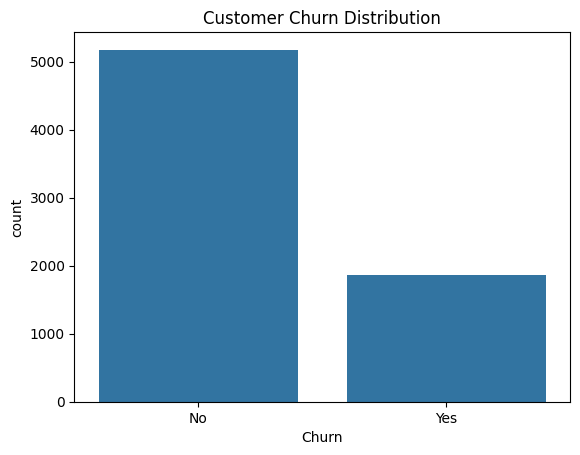

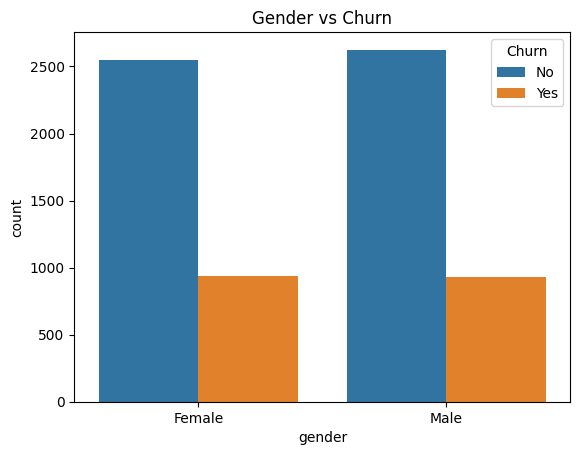

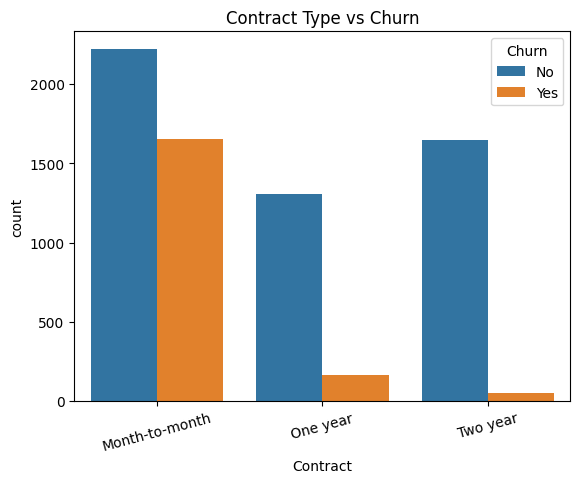

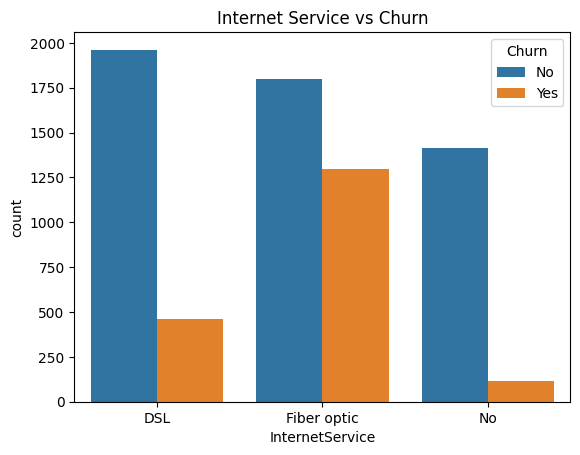

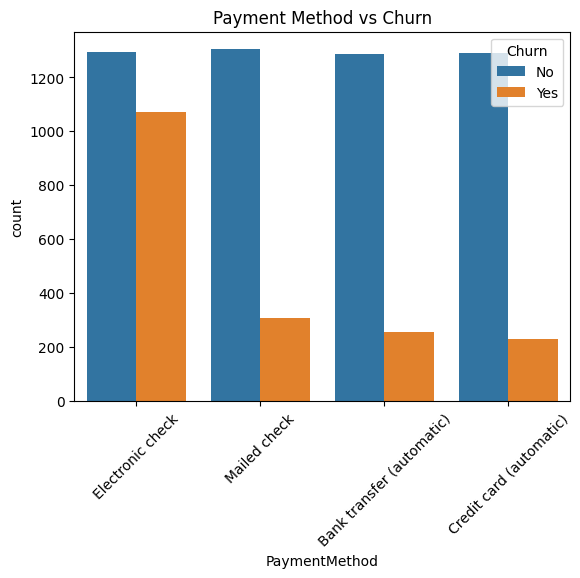

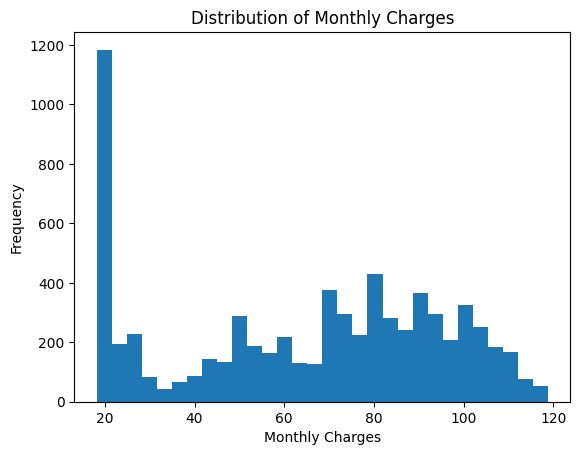

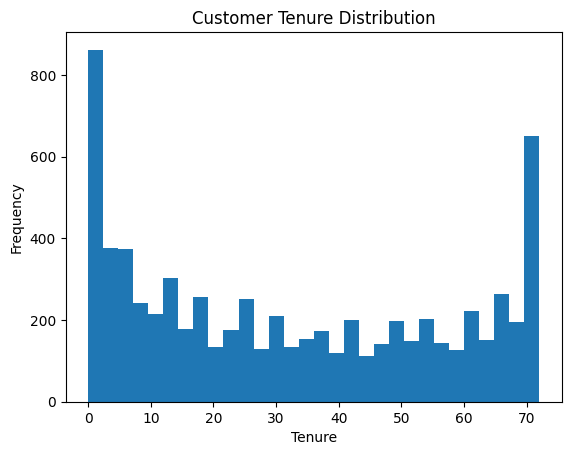

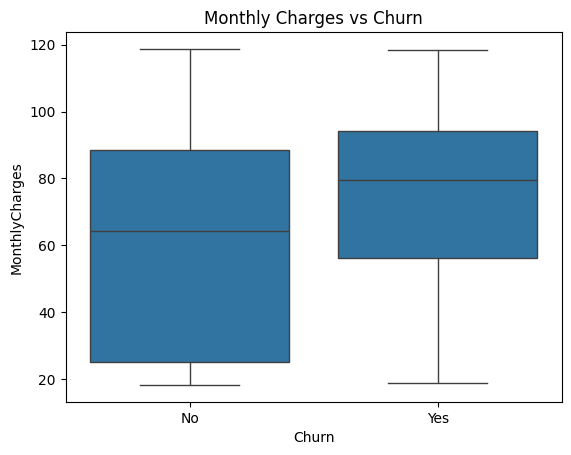

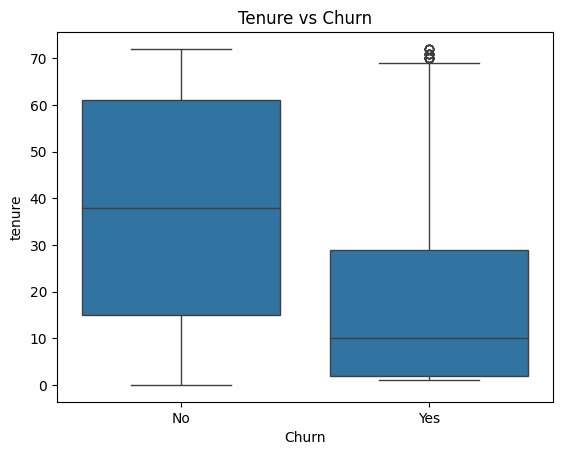

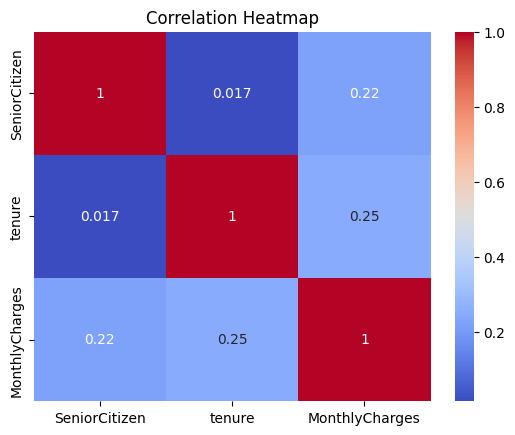

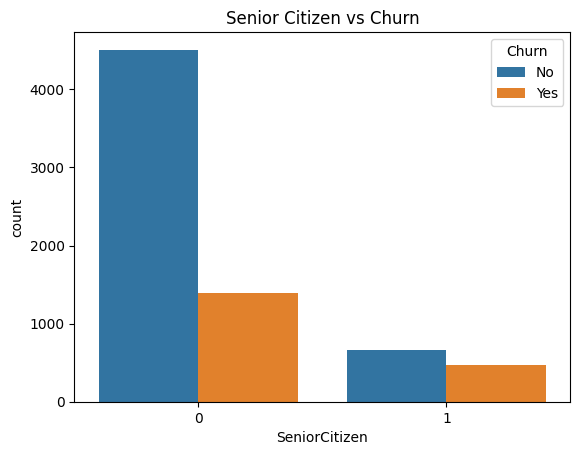

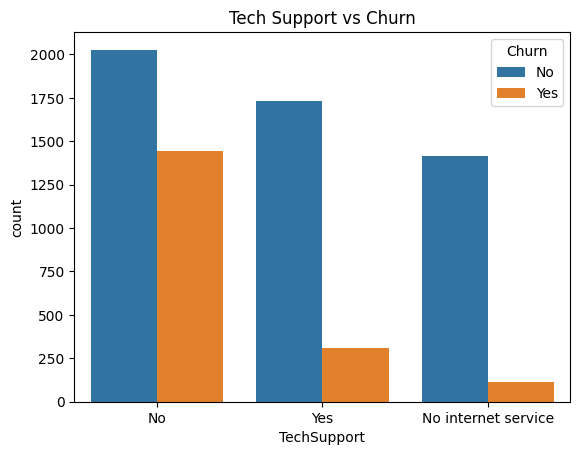

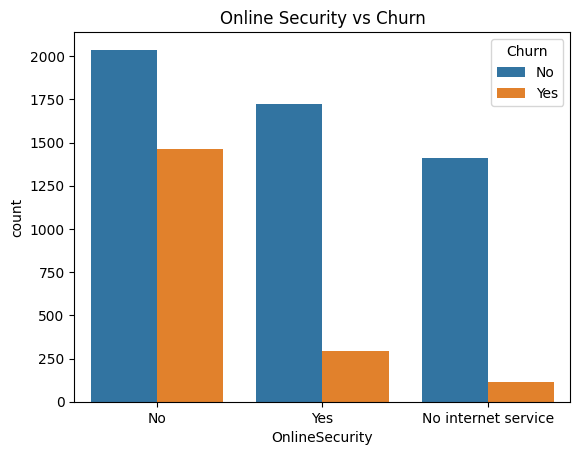

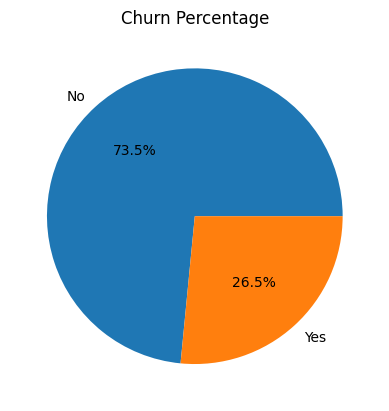

In [322]:
# =====================
# VISUALIZATIONS
# =====================


import seaborn as sns
import matplotlib.pyplot as plt

# To check wether more customers staywed or left
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

# To see wether gender affects churn
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

# To determine which contract type has the highest churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

# To see which internet service users churn most
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

# To identify payment methods linked to churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

# To understand how monthly charges are distributed
plt.hist(df['MonthlyCharges'], bins=30)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

# To see how long customers stay
plt.hist(df['tenure'], bins=30)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

# To compare charges between churned and retained customers
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# To compare customer tenure with churn behavior
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

# To identify relationships between numerical variables
numeric_data = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# To see wether senior citizens churn more
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Senior Citizen vs Churn")
plt.show()

# To check wether lack of tech support increses churn
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title("Tech Support vs Churn")
plt.show()

# To analyze the effect of online security on churn
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title("Online Security vs Churn")
plt.show()

# To show churn proportionality clearly
df['Churn'].value_counts().plot.pie( autopct='%1.1f%%' )
plt.title("Churn Percentage")
plt.ylabel('')
plt.show()





In [323]:
df.drop(['customerID','PhoneService','MultipleLines'], axis=1, inplace=True)

In [324]:
for columns in df.columns:
  print(df[columns].value_counts())
  print('========================')

gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
Stre

In [325]:
df['TotalCharges'].dtype

dtype('O')

In [326]:
# Total charges may load as text beacause of blank spaces so I coverted it to Numeric.
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [327]:
df['TotalCharges'].isnull().sum()

np.int64(11)

## FEATURE ENGINEERING

In [328]:
df['AvgMonthlySpend'] = (
    df['TotalCharges']/(df['tenure'] + 1)
)

# I created this column because,
# It helps to detect customers paying heavily over time
# It also gives better spending behaviour patterns
# It cvan help improve churn predictions

In [329]:
# --------------------------------------------------
# Service Count
# Customers using more services behave differently
# --------------------------------------------------

services=[
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
    ]

df['ServiceCount'] = (
    df[services]  == 'Yes'
    ).sum(axis=1)

# --------------------------------------------
# Customer Lifetime Value (CLV)
# Estimated customer value
# ---------------------------------------------

df['CLV'] = (
    df['MonthlyCharges']
    * df['tenure'] )



In [330]:
print("✅ Feature Engineering Completed!")
print(df[[
    'ServiceCount',
    'CLV',
    'AvgMonthlySpend'
    ]].head())

✅ Feature Engineering Completed!
   ServiceCount      CLV  AvgMonthlySpend
0             1    29.85        14.925000
1             2  1936.30        53.985714
2             2   107.70        36.050000
3             3  1903.50        40.016304
4             0   141.40        50.550000


In [331]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,ServiceCount,CLV
0,Female,0,Yes,No,1,DSL,No,Yes,No,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000,1,29.85
1,Male,0,No,No,34,DSL,Yes,No,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,53.985714,2,1936.30
2,Male,0,No,No,2,DSL,Yes,Yes,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000,2,107.70
3,Male,0,No,No,45,DSL,Yes,No,Yes,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304,3,1903.50
4,Female,0,No,No,2,Fiber optic,No,No,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000,0,141.40


## ENCODING

In [332]:
#...Changing the gender columns from text value(object) to int data type
#...male = 1
#...female= 0
df['gender'] = df['gender'].map({
    'Male': 1,
    'Female': 0
})

In [333]:
for col in df.columns:
    unique_vals = set(df[col].dropna().unique())

    if unique_vals == {'Yes', 'No'}:
        print(col)

Partner
Dependents
PaperlessBilling
Churn


In [334]:
yes_no_cols = [
    'Partner',
    'Dependents',
    'PaperlessBilling',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Churn'
]

for col in yes_no_cols:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0
    })

In [335]:
#..One-Hot Encoding on the remaining categorical columns in the dataset as shown below:

#...internet service;
#...0,0 = DSL
#...1,0 = Fiber optic
#...0,1 = No Internet Service

#...contract;
#..0,0 = Month-to-month
#..1,0 = One year
#..0,1 = Two year

#...0,0,0 = Bank transfer (automatic)
#...1,0,0 = Credit Card (Automatic)
#...0,1,0 = Electronic Check
#...0,0,1 = Mailed Check

In [336]:
categorical_cols = [
    'InternetService',
    'Contract',
    'PaymentMethod'
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first = True

)


In [337]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [338]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,AvgMonthlySpend,ServiceCount,CLV,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0.0,1.0,0.0,0.0,0.0,...,14.925000,1,29.85,0,0,0,0,0,1,0
1,1,0,0,0,34,1.0,0.0,1.0,0.0,0.0,...,53.985714,2,1936.30,0,0,1,0,0,0,1
2,1,0,0,0,2,1.0,1.0,0.0,0.0,0.0,...,36.050000,2,107.70,0,0,0,0,0,0,1
3,1,0,0,0,45,1.0,0.0,1.0,1.0,0.0,...,40.016304,3,1903.50,0,0,1,0,0,0,0
4,0,0,0,0,2,0.0,0.0,0.0,0.0,0.0,...,50.550000,0,141.40,1,0,0,0,0,1,0


In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   OnlineSecurity                         5517 non-null   float64
 6   OnlineBackup                           5517 non-null   float64
 7   DeviceProtection                       5517 non-null   float64
 8   TechSupport                            5517 non-null   float64
 9   StreamingTV                            5517 non-null   float64
 10  StreamingMovies                        5517 non-null   float64
 11  Pape

In [340]:
for col in df.columns:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].median())

In [341]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [342]:
print(X.shape)
print(y.shape)

(7043, 24)
(7043,)


In [343]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [344]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'tenure',
    'ServiceCount',
    'CLV',
    'TotalCharges'
]

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(
    X_train[scale_cols]
)

X_test[scale_cols] = scaler.transform(
    X_test[scale_cols]
)


In [345]:
check_cols = [
    'Partner',
    'Dependents',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'Churn'
]

df[check_cols].isnull().sum()

,0
Partner,0
Dependents,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0
StreamingTV,0
StreamingMovies,0
PaperlessBilling,0
Churn,0


In [346]:
print(X_train.isnull().sum())

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
AvgMonthlySpend                          0
ServiceCount                             0
CLV                                      0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMeth

In [347]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0
StreamingTV,0


In [348]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())


In [349]:
print(X_train.isnull().sum())

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
AvgMonthlySpend                          0
ServiceCount                             0
CLV                                      0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMeth

In [350]:
cat_cols = X_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    X_train[col] = X_train[col].fillna(X_train[col].mode()[0])


In [351]:
print(X_test.isnull().sum())

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
AvgMonthlySpend                          0
ServiceCount                             0
CLV                                      0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMeth

In [352]:
X_test[num_cols] = X_test[num_cols].fillna(X_test[num_cols].median())
for col in cat_cols:
    X_test[col] = X_test[col].fillna(X_test[col].mode()[0])

In [353]:
print(X_test.isnull().sum())

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
AvgMonthlySpend                          0
ServiceCount                             0
CLV                                      0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMeth

In [354]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0
StreamingTV,0


In [355]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,AvgMonthlySpend,ServiceCount,CLV,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0.0,1.0,0.0,0.0,0.0,...,14.925000,1,29.85,0,0,0,0,0,1,0
1,1,0,0,0,34,1.0,0.0,1.0,0.0,0.0,...,53.985714,2,1936.30,0,0,1,0,0,0,1
2,1,0,0,0,2,1.0,1.0,0.0,0.0,0.0,...,36.050000,2,107.70,0,0,0,0,0,0,1
3,1,0,0,0,45,1.0,0.0,1.0,1.0,0.0,...,40.016304,3,1903.50,0,0,1,0,0,0,0
4,0,0,0,0,2,0.0,0.0,0.0,0.0,0.0,...,50.550000,0,141.40,1,0,0,0,0,1,0
5,0,0,0,0,8,0.0,0.0,1.0,0.0,1.0,...,91.166667,3,797.20,1,0,0,0,0,1,0
6,1,0,0,1,22,0.0,1.0,0.0,0.0,1.0,...,84.756522,2,1960.20,1,0,0,0,1,0,0
7,0,0,0,0,10,1.0,0.0,0.0,0.0,0.0,...,27.445455,1,297.50,0,0,0,0,0,0,1
8,0,0,1,0,28,0.0,0.0,1.0,1.0,1.0,...,105.036207,4,2934.40,1,0,0,0,0,1,0
9,1,0,0,1,62,1.0,1.0,0.0,0.0,0.0,...,55.364286,2,3481.30,0,0,1,0,0,0,0


## TRAINING MY MODEL

In [356]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [357]:
y_pred = lr.predict(X_test)

In [358]:
from sklearn.metrics import accuracy_score
##===Accuracy===
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

#===Classification report====
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

#====Confusion matrix====
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

#====ROC-AUC Score====
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc)

Accuracy: 0.8026969481902059
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

[[933 102]
 [176 198]]
ROC-AUC: 0.8455966312743807


In [359]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, rf_pred)
)

Random Forest Accuracy: 0.7863733144073811


In [360]:
from sklearn.metrics import classification_report
# 1. Predictions for Logistic Regression
y_pred_lr = lr.predict(X_test)


# 2. Predictions for Random Forest
y_pred_rf = rf.predict(X_test)

print("================ LOGISTIC REGRESSION REPORT ================")
print(classification_report(y_test, y_pred_lr))
print("\n=================== RANDOM FOREST REPORT ===================")
print(classification_report(y_test, y_pred_rf))


================ LOGISTIC REGRESSION REPORT ================
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409


=================== RANDOM FOREST REPORT ===================
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



In [361]:
### Model Evaluation: Confusion Matrix Analysis
## To evaluate and compare the performance of our models on the unseen test dataset, we plot a **Confusion Matrix** for both the Logistic Regression and Random Forest models.
## The confusion matrix breaks down the model's predictions into a $2 \times 2$ grid:
#* **True Negatives (Top-Left):** Correctly predicted negative cases (Class 0).
#* **True Positives (Bottom-Right):** Correctly predicted positive cases (Class 1).
#* **False Positives (Top-Right):** "False Alarms"—cases where the model incorrectly predicted Class 1.
#* **False Negatives (Bottom-Left):** "Misses"—cases where the model missed an actual Class 1 event.

## A stronger model will show higher numbers concentrated along the diagonal from the top-left to the bottom-right, representing accurate classifications.



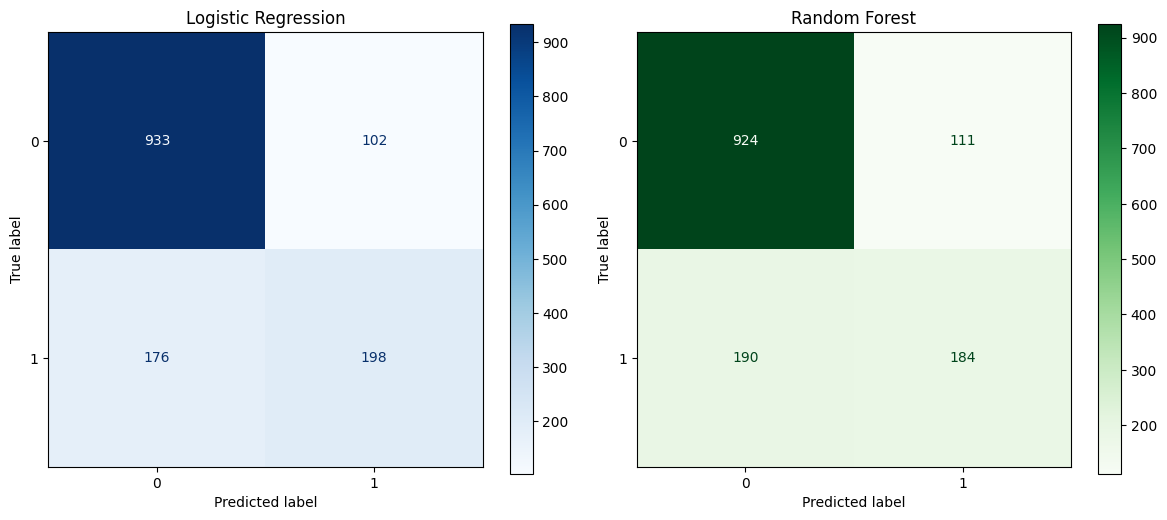

In [362]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Set up a side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Logistic Regression')

# Plot Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Random Forest')
plt.tight_layout()
plt.show()


In [363]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'AvgMonthlySpend', 'ServiceCount', 'CLV',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [364]:
print('Train columns:',list(X_train.columns))

Train columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'ServiceCount', 'CLV', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [365]:
new_customer= pd.DataFrame({

    'gender': [1],
    'SeniorCitizen': [0],
    'Partner': [1],
    'Dependents': [0],
    'tenure': [3],
    'OnlineSecurity': [0],
    'OnlineBackup': [1],
    'DeviceProtection': [0],
    'TechSupport': [0],
    'StreamingTV': [1],
    'StreamingMovies': [1],
    'PaperlessBilling': [1],
    'MonthlyCharges': [95],
    'TotalCharges': [300],
    'AvgMonthlySpend': [50],
    'ServiceCount': [3],
    'CLV': [427.50],
    'InternetService_Fiber optic': [1],
    'InternetService_No': [0],
    'Contract_One year': [0],
    'Contract_Two year': [0],
    'PaymentMethod_Credit card (automatic)': [0],
    'PaymentMethod_Electronic check': [1],
    'PaymentMethod_Mailed check': [0]

    })





In [366]:
new_customer = pd.DataFrame(customer_data)

In [367]:
#....1 = Customer will churn
#....0 = Customer will stay

prediction = lr.predict(new_customer)

print(prediction)

[1]


In [368]:
if prediction[0] == 1:
  print('Customer is likely to churn')
else:
  print('Customer is likely to stay')


Customer is likely to churn


In [369]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [370]:
import joblib
joblib.dump(lr, "best_churn_model.pkl")

['best_churn_model.pkl']

In [371]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [372]:
import joblib
lr = joblib.load("best_churn_model.pkl")
scaler = joblib.load("scaler.pkl")

print ("Model loaded sucessfully")

Model loaded sucessfully
